株価時系列を下記のように与える
```math
S_0, S_1, S_2, S_3, S_4...S_t
```
リターン時系列を下記のように与える
```math
R_t = \frac{S_{t+1}}{S_t}\\
R_0, R_1, R_2, ...
```
このリターン時系列は1次のマルコフ過程の内部変数から観測されるものとする
```math
R_t = r_t dt + \sigma_t dW
```
内部変数の時間発展は次のように表せるものとする。$`\Sigma_r, \Sigma_\sigma`$はハイパーパラメータであり、定数とする。
```math
r_{t+1} = r_t + \Sigma_r dW_r\\
\log \sigma_{t+1} =\log \sigma_t + \Sigma_\sigma dW_\sigma
```

問題設定\
今回は時系列で考えるのではなく1期間のリターンから内部変数の事後分布を求める問題とする。

事前分布
```math
r_t \sim N(a,A) \\
\log \sigma_t \sim N(b,B)
```

In [34]:
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [39]:
basic_model = pm.Model()

a = 0
A = 0.5
b = 0.01
B = 0.001

dt = 1.0/12.0
R = 0.25*dt

with basic_model:
    s_return = pm.Normal("s_return", mu=a, sigma = A)
    s_log_sigma = pm.Normal("s_log_sigma", mu=b, sigma = B)
    sigma = pm.Deterministic("s_sigma", pm.math.exp(s_log_sigma))

    R = pm.Normal("R", mu=s_return*dt, sigma=sigma*np.sqrt(dt), observed=R)

In [40]:
%time
with basic_model:
    # 1000 回、事後分布を抽出
    idata = pm.sample(draws=1000)

Initializing NUTS using jitter+adapt_diag...


CPU times: user 2 µs, sys: 1e+03 ns, total: 3 µs
Wall time: 3.1 µs


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [s_return, s_log_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [41]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

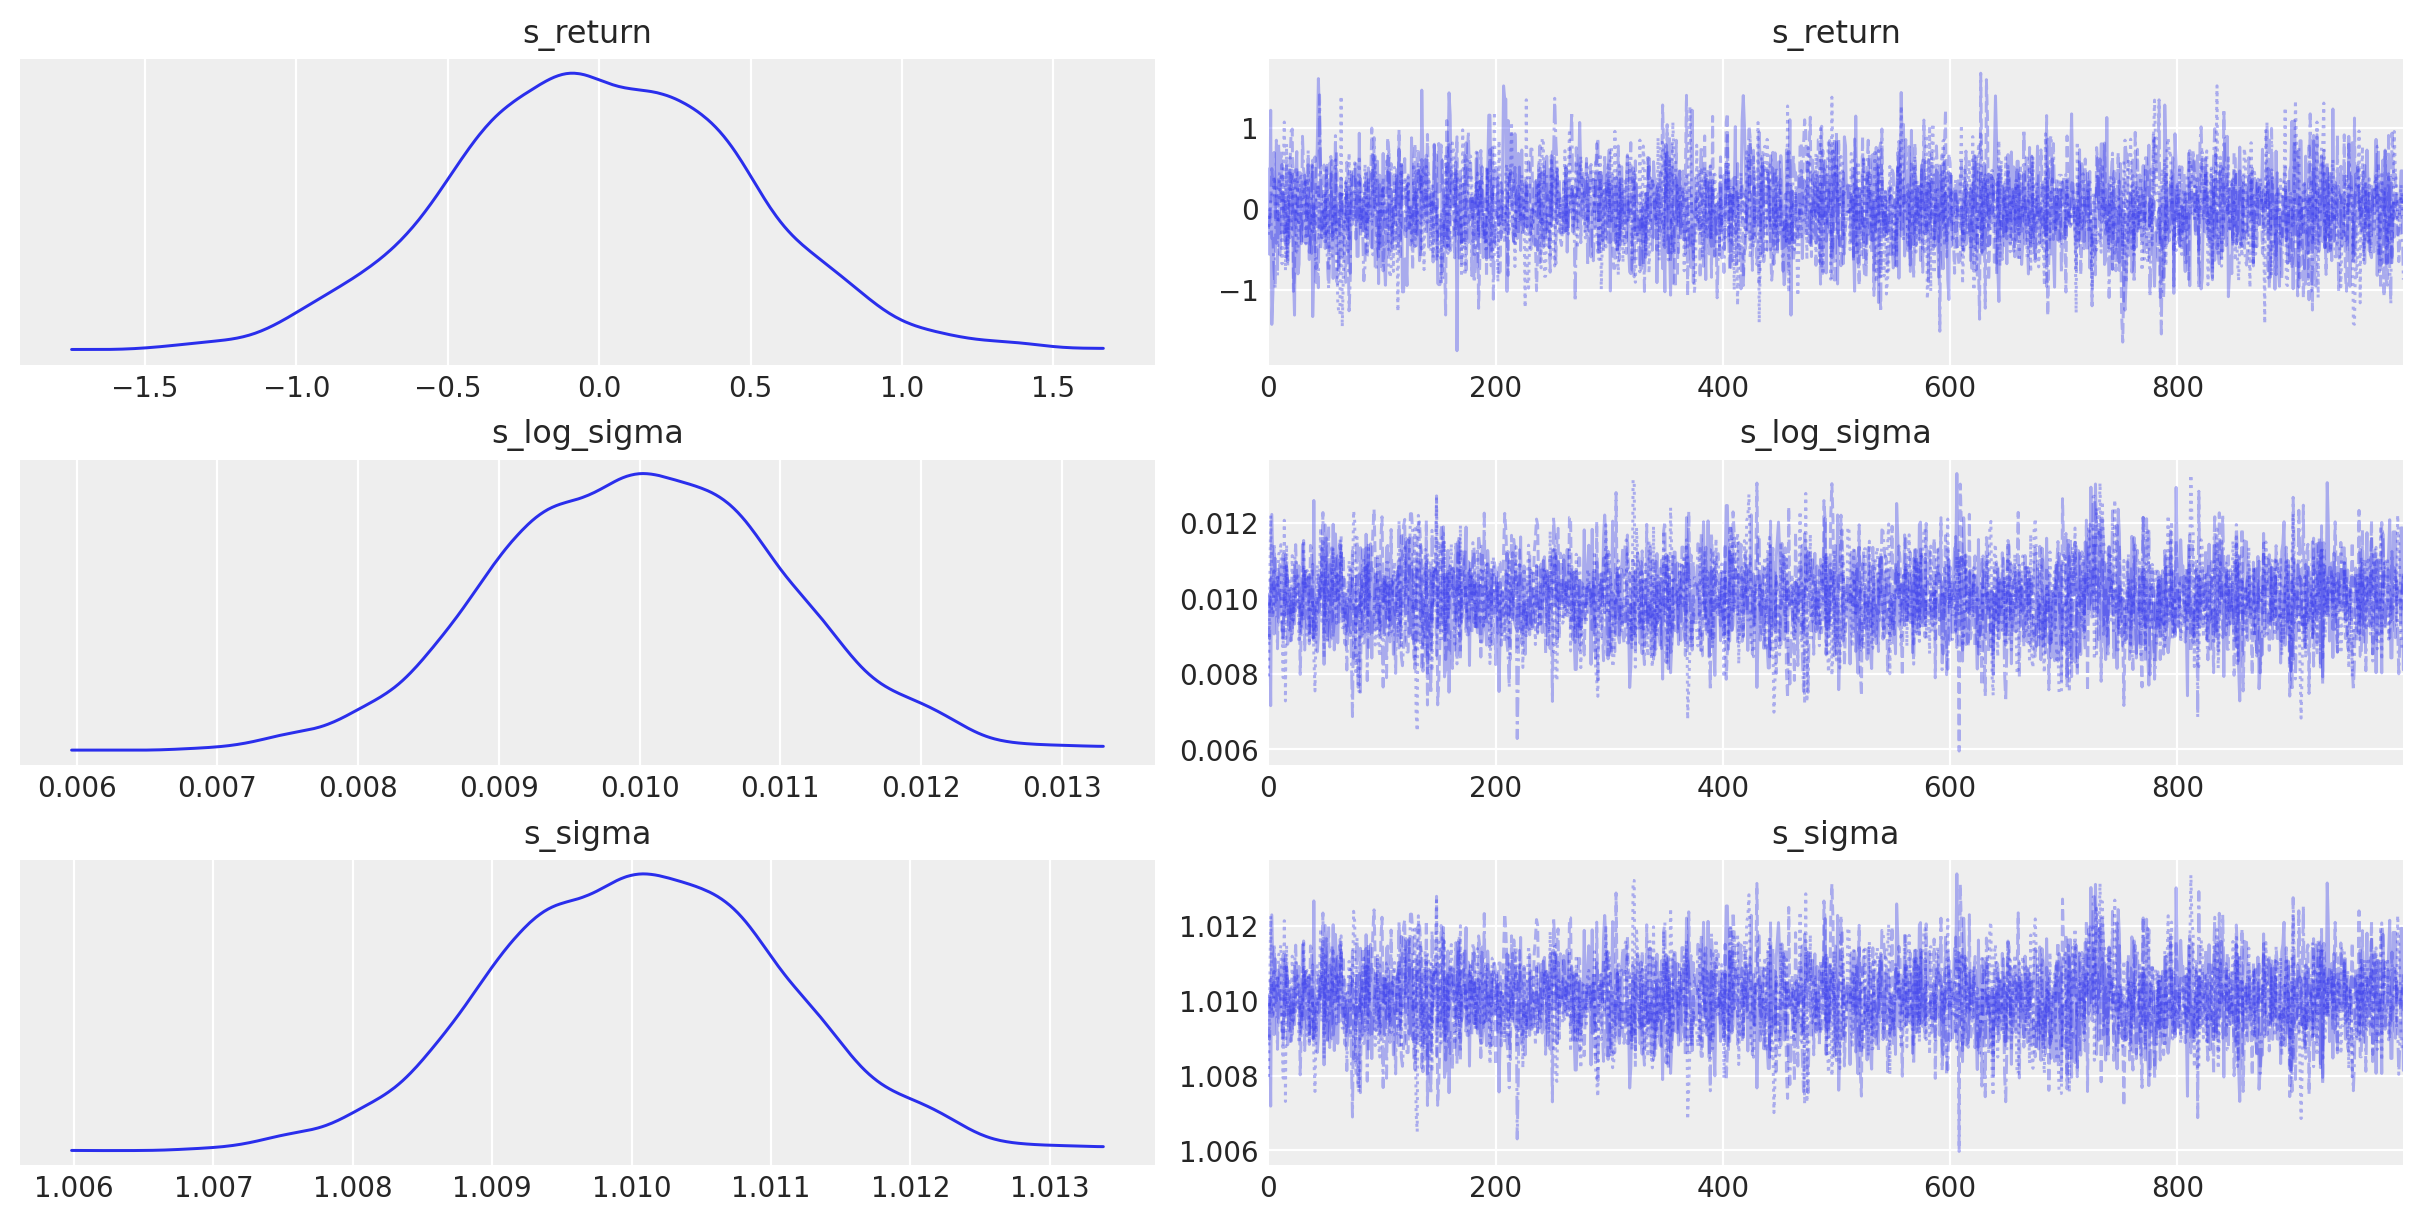

In [42]:
az.plot_trace(idata, combined=True);